In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

performance = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "GAM",
        "MLP"
    ],
    
    "Pre_MAE": [
        10.791538,
        9.273186,
        8.347060
    ],
    
    "Post_MAE": [
        10.662674,
        9.274655,
        8.922830
    ],
    
    "Pre_RMSE": [
        13.295435,
        11.422008,
        10.607984
    ],
    
    "Post_RMSE": [
        12.991109,
        11.452191,
        11.321583
    ],
    
    "Pre_R2": [
        0.431216,
        0.580214,
        0.637917
    ],
    
    "Post_R2": [
        0.403798,
        0.536683,
        0.547190
    ]
})

performance

,Model,Pre_MAE,Post_MAE,Pre_RMSE,Post_RMSE,Pre_R2,Post_R2
0,Linear Regression,10.791538,10.662674,13.295435,12.991109,0.431216,0.403798
1,GAM,9.273186,9.274655,11.422008,11.452191,0.580214,0.536683
2,MLP,8.347060,8.922830,10.607984,11.321583,0.637917,0.547190


In [3]:
performance["Delta_MAE"] = (
    performance["Post_MAE"] - performance["Pre_MAE"]
)

performance["Delta_RMSE"] = (
    performance["Post_RMSE"] - performance["Pre_RMSE"]
)

performance["Delta_R2"] = (
    performance["Post_R2"] - performance["Pre_R2"]
)

performance.round(3)

,Model,Pre_MAE,Post_MAE,Pre_RMSE,Post_RMSE,Pre_R2,Post_R2,Delta_MAE,Delta_RMSE,Delta_R2
0,Linear Regression,10.792,10.663,13.295,12.991,0.431,0.404,-0.129,-0.304,-0.027
1,GAM,9.273,9.275,11.422,11.452,0.580,0.537,0.001,0.030,-0.044
2,MLP,8.347,8.923,10.608,11.322,0.638,0.547,0.576,0.714,-0.091


In [4]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "GAM",
        "MLP"
    ],

    "Pre_CV_MAE": [
        10.997559,
        9.512864,
        8.869235
    ],

    "Post_CV_MAE": [
        10.887289,
        9.627249,
        8.876133
    ],

    "Pre_CV_RMSE": [
        13.415852,
        11.800951,
        11.333287
    ],

    "Post_CV_RMSE": [
        13.334864,
        11.946082,
        11.475750
    ],

    "Pre_CV_R2": [
        0.414172,
        0.546546,
        0.581800
    ],

    "Post_CV_R2": [
        0.381992,
        0.503665,
        0.542298
    ]
})

cv_comparison["Delta_CV_R2"] = (
    cv_comparison["Post_CV_R2"] -
    cv_comparison["Pre_CV_R2"]
)

cv_comparison.round(3)

,Model,Pre_CV_MAE,Post_CV_MAE,Pre_CV_RMSE,Post_CV_RMSE,Pre_CV_R2,Post_CV_R2,Delta_CV_R2
0,Linear Regression,10.998,10.887,13.416,13.335,0.414,0.382,-0.032
1,GAM,9.513,9.627,11.801,11.946,0.547,0.504,-0.043
2,MLP,8.869,8.876,11.333,11.476,0.582,0.542,-0.040


In [5]:
import pandas as pd
import numpy as np

# ============================================================
# EXACT PRE-PANDEMIC SHAP VALUES
# extracted from your 2017–2018 notebook
# ============================================================

pre_shap = pd.DataFrame({
    "Feature": [
        "systolic_bp",
        "alt",
        "bun",
        "hba1c",
        "ast",
        "diastolic_bp",
        "glucose",
        "bmi",
        "albumin",
        "hdl",
        "total_cholesterol",
        "sex",
        "creatinine",
        "ggt"
    ],
    "Pre_SHAP": [
        5.932276,
        3.342318,
        3.327239,
        2.773763,
        2.052520,
        1.939188,
        1.461846,
        1.325668,
        1.267837,
        1.094786,
        0.869562,
        0.632777,
        0.407307,
        0.273989
    ]
})


# ============================================================
# EXACT POST-PANDEMIC SHAP VALUES
# extracted from your 2021–2023 notebook
# ============================================================

post_shap = pd.DataFrame({
    "Feature": [
        "systolic_bp",
        "diastolic_bp",
        "bun",
        "hba1c",
        "creatinine",
        "alt",
        "hdl",
        "albumin",
        "sex",
        "ast",
        "glucose",
        "total_cholesterol",
        "bmi",
        "ggt"
    ],
    "Post_SHAP": [
        5.312506,
        2.927501,
        2.891965,
        2.380626,
        2.070730,
        1.726648,
        1.474953,
        1.460902,
        1.151394,
        1.003189,
        1.001908,
        0.743012,
        0.566276,
        0.057913
    ]
})


# ============================================================
# MERGE
# ============================================================

shap_compare = pd.merge(
    pre_shap,
    post_shap,
    on="Feature",
    how="inner"
)


# ============================================================
# NORMALISED RELATIVE IMPORTANCE
# ============================================================

shap_compare["Pre_Percent"] = (
    shap_compare["Pre_SHAP"] /
    shap_compare["Pre_SHAP"].sum()
) * 100

shap_compare["Post_Percent"] = (
    shap_compare["Post_SHAP"] /
    shap_compare["Post_SHAP"].sum()
) * 100

shap_compare["Delta_Percent"] = (
    shap_compare["Post_Percent"]
    - shap_compare["Pre_Percent"]
)


# ============================================================
# RANKS
# ============================================================

shap_compare["Pre_Rank"] = (
    shap_compare["Pre_SHAP"]
    .rank(ascending=False, method="min")
    .astype(int)
)

shap_compare["Post_Rank"] = (
    shap_compare["Post_SHAP"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# Negative = moved UP in importance
# Positive = moved DOWN in importance
shap_compare["Rank_Change"] = (
    shap_compare["Post_Rank"]
    - shap_compare["Pre_Rank"]
)


# ============================================================
# FINAL TABLE
# ============================================================

shap_final = shap_compare[
    [
        "Feature",
        "Pre_SHAP",
        "Post_SHAP",
        "Pre_Rank",
        "Post_Rank",
        "Rank_Change",
        "Pre_Percent",
        "Post_Percent",
        "Delta_Percent"
    ]
].sort_values("Pre_Rank")

print(shap_final.round(3).to_string(index=False))

          Feature  Pre_SHAP  Post_SHAP  Pre_Rank  Post_Rank  Rank_Change  Pre_Percent  Post_Percent  Delta_Percent
      systolic_bp     5.932      5.313         1          1            0       22.217        21.448         -0.770
              alt     3.342      1.727         2          6            4       12.518         6.971         -5.547
              bun     3.327      2.892         3          3            0       12.461        11.675         -0.786
            hba1c     2.774      2.381         4          4            0       10.388         9.611         -0.777
              ast     2.053      1.003         5         10            5        7.687         4.050         -3.637
     diastolic_bp     1.939      2.928         6          2           -4        7.263        11.819          4.556
          glucose     1.462      1.002         7         11            4        5.475         4.045         -1.430
              bmi     1.326      0.566         8         13            5        

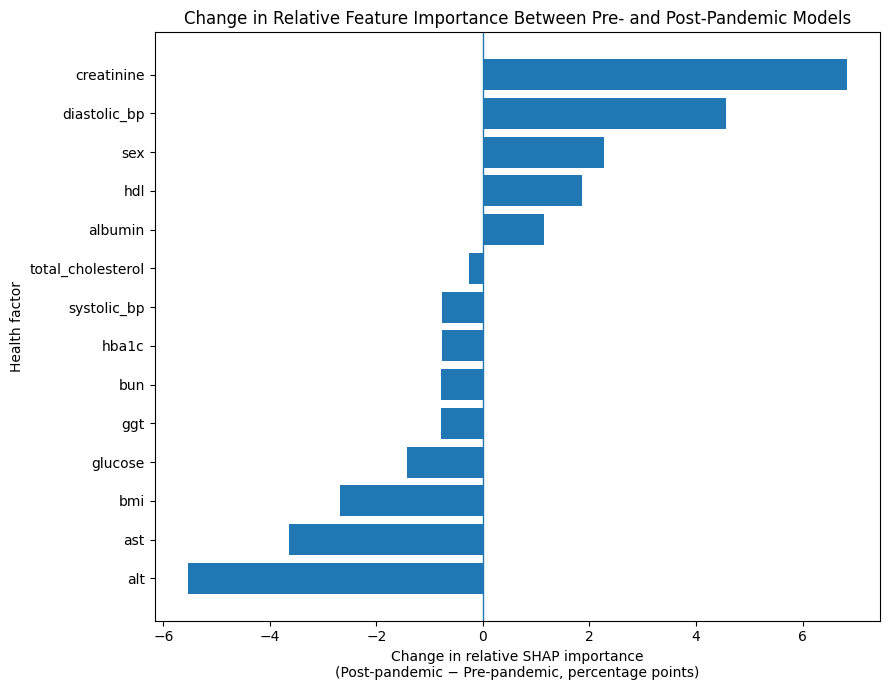

In [7]:
change_plot = shap_final.sort_values(
    "Delta_Percent"
)

plt.figure(figsize=(9, 7))

plt.barh(
    change_plot["Feature"],
    change_plot["Delta_Percent"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel(
    "Change in relative SHAP importance\n"
    "(Post-pandemic − Pre-pandemic, percentage points)"
)

plt.ylabel("Health factor")

plt.title(
    "Change in Relative Feature Importance "
    "Between Pre- and Post-Pandemic Models"
)

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pre_curves = pd.read_csv(
    "pre_gam_curves.csv"
)

post_curves = pd.read_csv(
    "post_gam_curves.csv"
)

print(pre_curves.shape)
print(post_curves.shape)

(1000, 4)
(1000, 4)


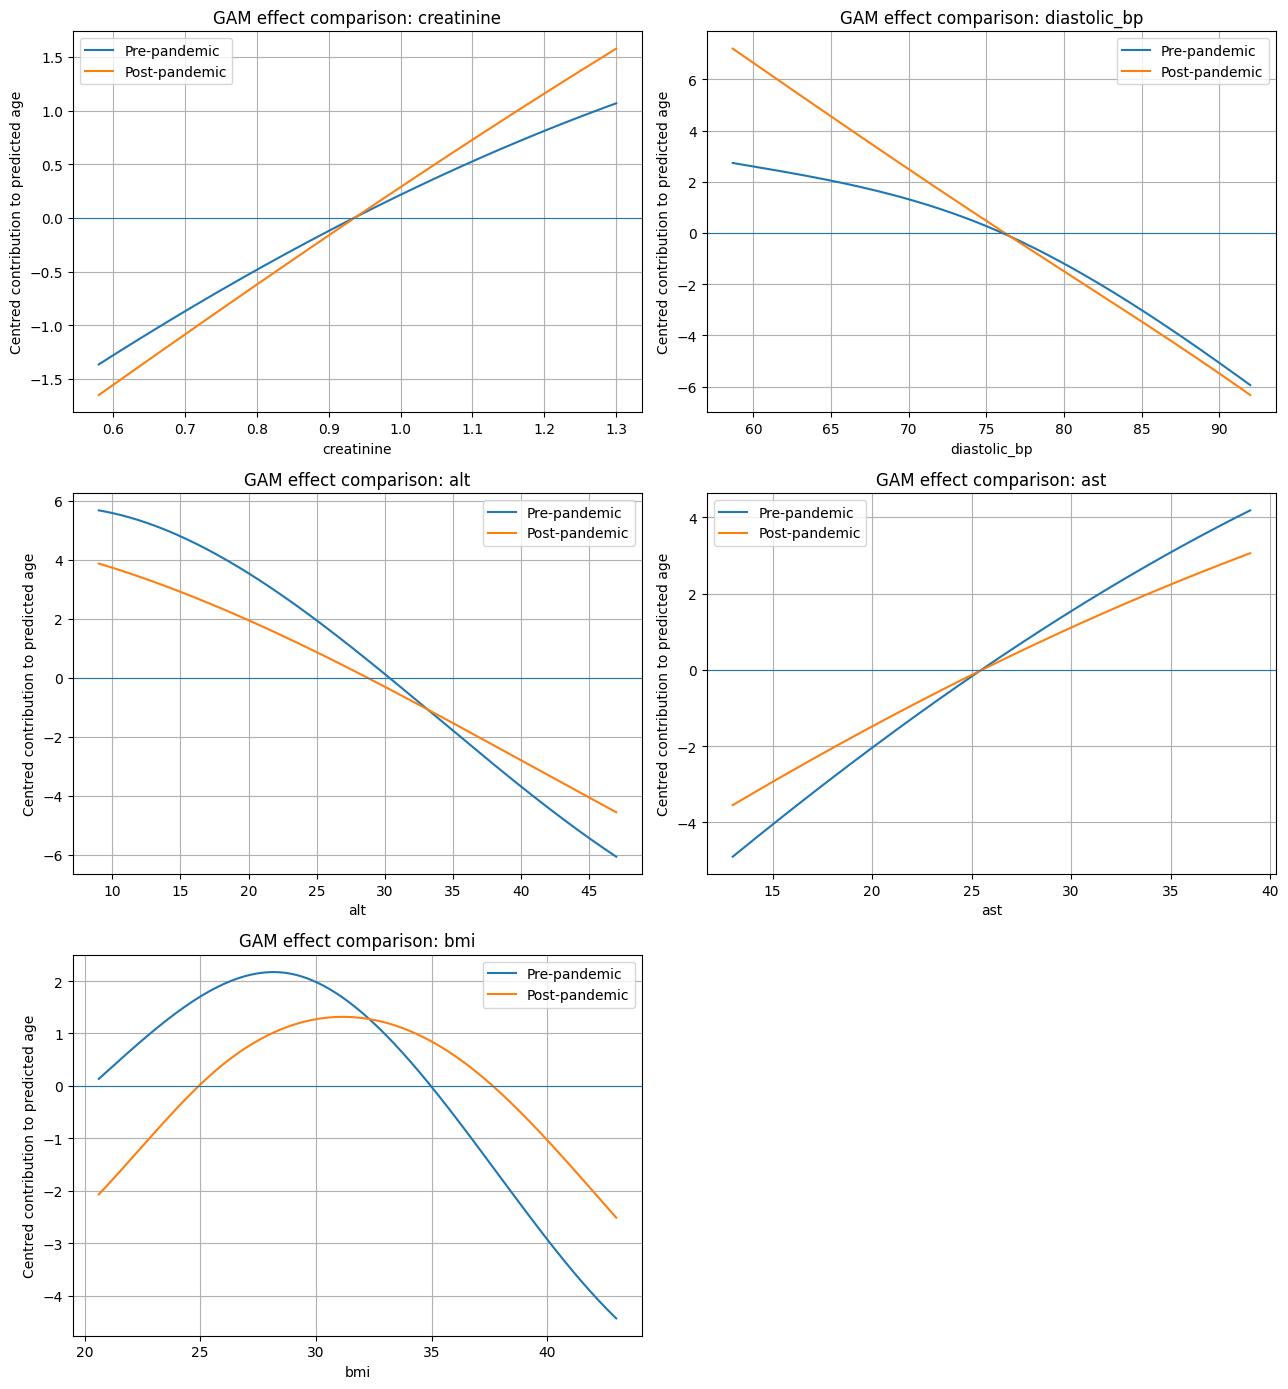

In [2]:
features_to_compare = [
    "creatinine",
    "diastolic_bp",
    "alt",
    "ast",
    "bmi"
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(13, 14)
)

axes = axes.flatten()

for i, feature in enumerate(features_to_compare):

    pre = pre_curves[
        pre_curves["Feature"] == feature
    ].copy()

    post = post_curves[
        post_curves["Feature"] == feature
    ].copy()

    # Find common range
    common_low = max(
        pre["Value"].min(),
        post["Value"].min()
    )

    common_high = min(
        pre["Value"].max(),
        post["Value"].max()
    )

    # Common x grid
    common_grid = np.linspace(
        common_low,
        common_high,
        200
    )

    # Interpolate curves onto identical x values
    pre_effect = np.interp(
        common_grid,
        pre["Value"],
        pre["Effect"]
    )

    post_effect = np.interp(
        common_grid,
        post["Value"],
        post["Effect"]
    )

    axes[i].plot(
        common_grid,
        pre_effect,
        label="Pre-pandemic"
    )

    axes[i].plot(
        common_grid,
        post_effect,
        label="Post-pandemic"
    )

    axes[i].axhline(
        0,
        linewidth=0.8
    )

    axes[i].set_title(
        f"GAM effect comparison: {feature}"
    )

    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(
        "Centred contribution to predicted age"
    )

    axes[i].legend()
    axes[i].grid(True)


# Remove unused subplot
for j in range(
    len(features_to_compare),
    len(axes)
):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [3]:
curve_difference_results = []

for feature in features_to_compare:

    pre = pre_curves[
        pre_curves["Feature"] == feature
    ].copy()

    post = post_curves[
        post_curves["Feature"] == feature
    ].copy()

    common_low = max(
        pre["Value"].min(),
        post["Value"].min()
    )

    common_high = min(
        pre["Value"].max(),
        post["Value"].max()
    )

    common_grid = np.linspace(
        common_low,
        common_high,
        200
    )

    pre_effect = np.interp(
        common_grid,
        pre["Value"],
        pre["Effect"]
    )

    post_effect = np.interp(
        common_grid,
        post["Value"],
        post["Effect"]
    )

    difference = (
        post_effect - pre_effect
    )

    mean_absolute_difference = (
        np.mean(np.abs(difference))
    )

    maximum_absolute_difference = (
        np.max(np.abs(difference))
    )

    curve_difference_results.append({
        "Feature": feature,
        "Mean_Absolute_Curve_Difference":
            mean_absolute_difference,
        "Maximum_Absolute_Curve_Difference":
            maximum_absolute_difference
    })


curve_difference_table = pd.DataFrame(
    curve_difference_results
).sort_values(
    "Mean_Absolute_Curve_Difference",
    ascending=False
)

print(
    curve_difference_table
    .round(3)
    .to_string(index=False)
)

     Feature  Mean_Absolute_Curve_Difference  Maximum_Absolute_Curve_Difference
         bmi                           1.349                              2.203
diastolic_bp                           1.208                              4.467
         alt                           1.136                              1.912
         ast                           0.630                              1.353
  creatinine                           0.201                              0.509


In [4]:
import pandas as pd

pre_perm = pd.read_csv("pre_permutation_importance.csv")
post_perm = pd.read_csv("post_permutation_importance.csv")

perm_compare = pre_perm.merge(
    post_perm,
    on="Feature"
)

# Normalize to relative importance (%)
perm_compare["Pre_Percent"] = (
    perm_compare["Pre_Permutation"] /
    perm_compare["Pre_Permutation"].sum()
) * 100

perm_compare["Post_Percent"] = (
    perm_compare["Post_Permutation"] /
    perm_compare["Post_Permutation"].sum()
) * 100

perm_compare["Delta_Percent"] = (
    perm_compare["Post_Percent"] -
    perm_compare["Pre_Percent"]
)

# Rankings
perm_compare["Pre_Rank"] = (
    perm_compare["Pre_Permutation"]
    .rank(ascending=False, method="min")
    .astype(int)
)

perm_compare["Post_Rank"] = (
    perm_compare["Post_Permutation"]
    .rank(ascending=False, method="min")
    .astype(int)
)

perm_compare["Rank_Change"] = (
    perm_compare["Post_Rank"] -
    perm_compare["Pre_Rank"]
)

perm_final = perm_compare[
    [
        "Feature",
        "Pre_Permutation",
        "Post_Permutation",
        "Pre_Rank",
        "Post_Rank",
        "Rank_Change",
        "Pre_Percent",
        "Post_Percent",
        "Delta_Percent"
    ]
].sort_values("Pre_Rank")

print(perm_final.round(3).to_string(index=False))

          Feature  Pre_Permutation  Post_Permutation  Pre_Rank  Post_Rank  Rank_Change  Pre_Percent  Post_Percent  Delta_Percent
      systolic_bp            0.398             0.412         1          1            0       32.560        36.263          3.703
            hba1c            0.167             0.150         2          2            0       13.626        13.245         -0.382
              bun            0.132             0.129         3          3            0       10.769        11.365          0.596
              alt            0.117             0.055         4          5            1        9.594         4.880         -4.714
     diastolic_bp            0.094             0.121         5          4           -1        7.670        10.699          3.029
          glucose            0.064             0.046         6          7            1        5.212         4.089         -1.123
          albumin            0.053             0.043         7          8            1        4.2